# FireSpec — Notebook 03: Live Fuel Moisture Content (LFMC)

This is the third notebook of the FireSpec submission to the
[Planet Tanager Open Data Competition](https://www.planet.com/tanager-open-data-competition/).
Notebook 01 established *what data we have*; Notebook 02 turned it into a burn-severity
product for the January 2025 Palisades/Eaton fires. This notebook targets a different — and
largely unaddressed — half of wildfire risk: **not what already burned, but what is about to.**
Live Fuel Moisture Content (LFMC), the percentage of water per unit dry mass in living
vegetation, is one of the strongest physical drivers of fire *ignition probability* and
*fire behavior* once ignited. Chaparral and coastal-sage fuels typically ignite readily once
LFMC drops below roughly 60–79% (Dennison & Moritz 2009); the Santa Ana-wind-driven Palisades
and Eaton fires themselves ignited into exceptionally dry, wind-cured chaparral.

## Why hyperspectral for water detection

Operational LFMC monitoring today comes from two sources: sparse in-situ field sampling
(destructive, weekly-to-monthly cadence, a few hundred sites nationwide via the USFS
National Fuel Moisture Database) and broadband-satellite proxies (MODIS/VIIRS NDVI, NDII,
or land-surface temperature — indirect, coarse, and only weakly correlated with canopy
water content). Neither resolves water *directly*. Liquid water in leaf tissue has three
well-characterized absorption features in the reflective infrared:

| Feature | Wavelength | Physical origin |
|---|---|---|
| O–H stretch first overtone | **970 nm** | Primary liquid-water absorption band, resolvable with narrow-band sensors |
| O–H combination band | **1200 nm** | Secondary water feature, less saturated at high LFMC than 970 nm |
| O–H stretch overtone | **1660 nm** (nominal) | Classic third water-sensitive region — **see the Tanager-specific gotcha below** |

A 10-band multispectral sensor blurs all three features into one or two wide bins.
Tanager-1's 426 contiguous ~5 nm bands resolve each feature's *shape*, not just its presence —
this is the entire premise of hyperspectral LFMC retrieval (Peterson & Roberts 2014; Quan et
al. 2021) and the reason FireSpec claims it as **the first satellite hyperspectral LFMC
product** attempted for the January 2025 LA-area fire complex (see the Discussion section for
what that claim does and does not cover).

**Tanager-specific gotcha — TD-9 (SAI1660 dropped).** The nominal 1660 nm water feature sits
inside Tanager's 1530–1790 nm atmospheric water-vapor absorption window (see
`BAD_BAND_RANGES` gotcha in the project documentation), where the sensor's own atmospheric
correction collapses surface reflectance to ~0.004 — essentially sensor noise, not a water
signal. `tanager.compute_lfmc_indices()` drops `SAI1660` entirely for this reason and instead
reports a **1700 nm** convex-hull absorption depth (just outside the atmospheric window) as
the third water feature. We follow that convention throughout this notebook.

## Two-tier approach

Mirroring `tanager.lfmc`'s design:

* **Tier 1 — Spectral indices** (§3–4): SAI970/SAI1200 (Quan et al. 2021), three NDWI
  variants, the Water Index (Peñuelas et al. 1993), and convex-hull continuum-removal band
  depths. Fast, interpretable, no training data required — but not a calibrated LFMC percent.
* **Tier 2 — PLSR regression** (§5–6): a full-spectrum Partial Least Squares model trained
  against ground-truth LFMC observations (Peterson & Roberts 2014), producing a calibrated
  per-pixel LFMC percent map plus an uncertainty layer and a fire-danger threshold flag.

Published accuracy for this general approach — AVIRIS airborne hyperspectral, leaf-level
validation — is **R² = 0.72–0.94** (Peterson & Roberts 2014); canopy-level (mixed-pixel,
satellite) accuracy is typically lower due to background soil, litter, and canopy-structure
mixing. We return to this benchmark honestly in §5 once real vs. synthetic training data is
discussed.

In [1]:
import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import tanager
from tanager.config import SENSOR, FIRE_SCENES, DATA_DIR
from tanager.masks import nodata_mask, cloud_mask, water_mask, apply_masks
from tanager.spectral import mask_bad_bands
from tanager.lfmc import compute_lfmc_indices, train_lfmc_plsr, predict_lfmc, load_globe_lfmc

logging.basicConfig(level=logging.WARNING)
%matplotlib inline

print(f"tanager package version: {tanager.__version__}")
print(
    f"Sensor: {SENSOR.name}, {SENSOR.n_bands} bands, "
    f"{SENSOR.wavelength_min_nm}-{SENSOR.wavelength_max_nm} nm, "
    f"{SENSOR.spatial_resolution_m} m GSD"
)

tanager package version: 0.1.0
Sensor: Tanager-1, 426 bands, 380-2500 nm, 30 m GSD


## 1. Data Loading

**Scene choice.** LFMC characterizes *living* vegetation, so the most useful scene for a fire
danger assessment is not the freshly-burned surface (dominated by char/ash — Notebook 02's
subject) but the vegetation that is still standing and could carry the *next* fire — inside
the Notebook 02 crop that didn't burn, and in the surrounding unburned wildland-urban
interface. We use `20250407_192235_24_4001`, the early-recovery-window scene
(~90 days post-ignition) over the Hughes fire footprint area, which is entirely live/recovering
vegetation and chaparral rather than active char. `tanager.config.FIRE_SCENES` carries the
catalog metadata for context.

In [2]:
SCENE_ID = "20250407_192235_24_4001"
scene_meta = FIRE_SCENES[SCENE_ID]
print(f"{SCENE_ID}: phase={scene_meta['phase']!r} — {scene_meta['notes']}")
print(f"Acquired: {scene_meta['datetime']} ({scene_meta['days_relative_to_ignition']:+d} days from ignition)")

scene_path = DATA_DIR / f"{SCENE_ID}_ortho_sr_hdf5.h5"
if not scene_path.exists():
    raise FileNotFoundError(
        f"{scene_path} not found. Download it first, e.g.:\n"
        "  tanager.download_scene(item, 'ortho_sr_hdf5', DATA_DIR)"
    )

t0 = time.time()
raw = tanager.load_ortho_scene(scene_path)
print(
    f"Loaded {dict(raw.sizes)} in {time.time() - t0:.1f}s "
    f"(data_var={raw.attrs.get('data_var')!r}, crs={raw.attrs.get('crs')})"
)

20250407_192235_24_4001: phase='early-recovery' — Early recovery (~90 days post-ignition); primary swath
Acquired: 2025-04-07T19:22:35Z (+90 days from ignition)


Loaded {'wavelength': 426, 'y': 869, 'x': 1039} in 6.9s (data_var='surface_reflectance', crs=EPSG:32611)


**Quality masking.** As in Notebook 02, we stack the standard no-data + cloud/cirrus + water
masks before any index math — LFMC's water-absorption features are exactly the kind of signal
that a stray cloud-edge or water pixel can fake.

In [3]:
mask_list = [nodata_mask(raw)]
try:
    mask_list.append(cloud_mask(raw, filepath=scene_path))
except Exception as exc:
    print(f"cloud_mask not applied: {exc}")
try:
    mask_list.append(water_mask(raw))
except Exception as exc:
    print(f"water_mask not applied: {exc}")

masked = apply_masks(raw, mask_list)
data_var = raw.attrs.get("data_var", "surface_reflectance")
total_px = int(raw.sizes["y"] * raw.sizes["x"])
valid_px = int(np.isfinite(masked[data_var].isel(wavelength=0).values).sum())
print(
    f"Applied {len(mask_list)} masks; valid pixels {valid_px:,}/{total_px:,} "
    f"({100.0 * valid_px / total_px:.1f}%)"
)

Applied 3 masks; valid pixels 683,948/902,891 (75.8%)


## 2. Spectral Water Indices

`tanager.compute_lfmc_indices()` computes the full Tier-1 water-sensitive index stack in one
call:

* **SAI970, SAI1200** — Spectral Absorption Index (Quan et al. 2021): the relative depth of a
  straight-line-continuum-removed absorption feature at each wavelength,
  `SAI = (R_continuum − R_target) / R_continuum`, clipped to `[0, 1]`. Higher = deeper
  absorption = more water.
* **NDWI_1240 / NDWI_1640 / NDWI_2130** — three Normalized Difference Water Index variants
  (Gao 1996), `(R860 − R_target) / (R860 + R_target)`, each probing water sensitivity at a
  different SWIR distance from the NIR reference.
* **WI** — the Peñuelas et al. (1993) Water Index, `R900 / R970`; values below 1 indicate
  absorption at the 970 nm feature.
* **CR_depths** — convex-hull continuum-removal band depths at 970, 1200, 1700, and 2100 nm
  (§3 below covers this in detail).

**Verifying a documented performance gotcha.** Project documentation records
a known issue as: *"LFMC continuum removal too slow for full scenes (>4min killed); only 256×256 crops
work."* That finding is real and dates to Phase 3 validation. Per the project's own
verify-before-trusting-a-claim discipline, we don't take a documented gotcha at face value
mid-session without re-checking it against the current code: `tanager.spectral.continuum_removal`
(which `compute_lfmc_indices` calls internally for `CR_depths`) was subsequently vectorized —
an upper-hull monotone-chain core with `joblib`-chunked parallelism across ~25k-pixel chunks —
and `scripts/run_pipeline.py`'s own remediation notes confirm the 256×256 crop workaround was
**removed** once that landed, because the full ~900k-pixel scene now fits comfortably inside
the runtime budget. We re-verify that directly below by timing the full-scene call ourselves,
rather than re-imposing a crop that the code no longer needs.

In [4]:
t0 = time.time()
indices = compute_lfmc_indices(masked)
elapsed = time.time() - t0
print(
    f"compute_lfmc_indices on the full {total_px:,}-pixel scene "
    f"(including convex-hull CR_depths): {elapsed:.1f}s"
)
print(f"Variables: {list(indices.data_vars)}")
for name, da in indices.data_vars.items():
    if "cr_target" in da.dims:
        continue
    v = np.asarray(da.values, dtype=np.float64)
    finite = np.isfinite(v)
    print(
        f"  {name:10s}: n_finite={int(finite.sum()):>7,}  "
        f"mean={np.nanmean(v):+.3f}  p50={np.nanmedian(v):+.3f}"
    )

compute_lfmc_indices on the full 902,891-pixel scene (including convex-hull CR_depths): 41.6s
Variables: ['SAI970', 'SAI1200', 'NDWI_1240', 'NDWI_1640', 'NDWI_2130', 'WI', 'CR_depths']
  SAI970    : n_finite=683,948  mean=+0.073  p50=+0.074
  SAI1200   : n_finite=683,948  mean=+0.076  p50=+0.074
  NDWI_1240 : n_finite=683,948  mean=-0.042  p50=-0.045
  NDWI_1640 : n_finite=683,948  mean=+0.062  p50=+0.051
  NDWI_2130 : n_finite=683,948  mean=+0.296  p50=+0.290
  WI        : n_finite=683,948  mean=+1.031  p50=+1.030


**Confirmed:** the full-scene run above completed in the time printed — well under the
historical 4-minute failure threshold in the performance issue, and far from the crop-only workaround the task
brief for this notebook initially called for. All index maps below therefore cover the entire
scene rather than an interior tile. (the project's tech-debt table has not
been updated to reflect this fix — flagged separately as a documentation gap, not something
this notebook's code needs to work around.)

The panel below renders each index with `tanager.plot_map()` — the same house plotting
function used throughout FireSpec — using a robust 2nd/98th-percentile stretch per index so no
single outlier band washes out the color scale.

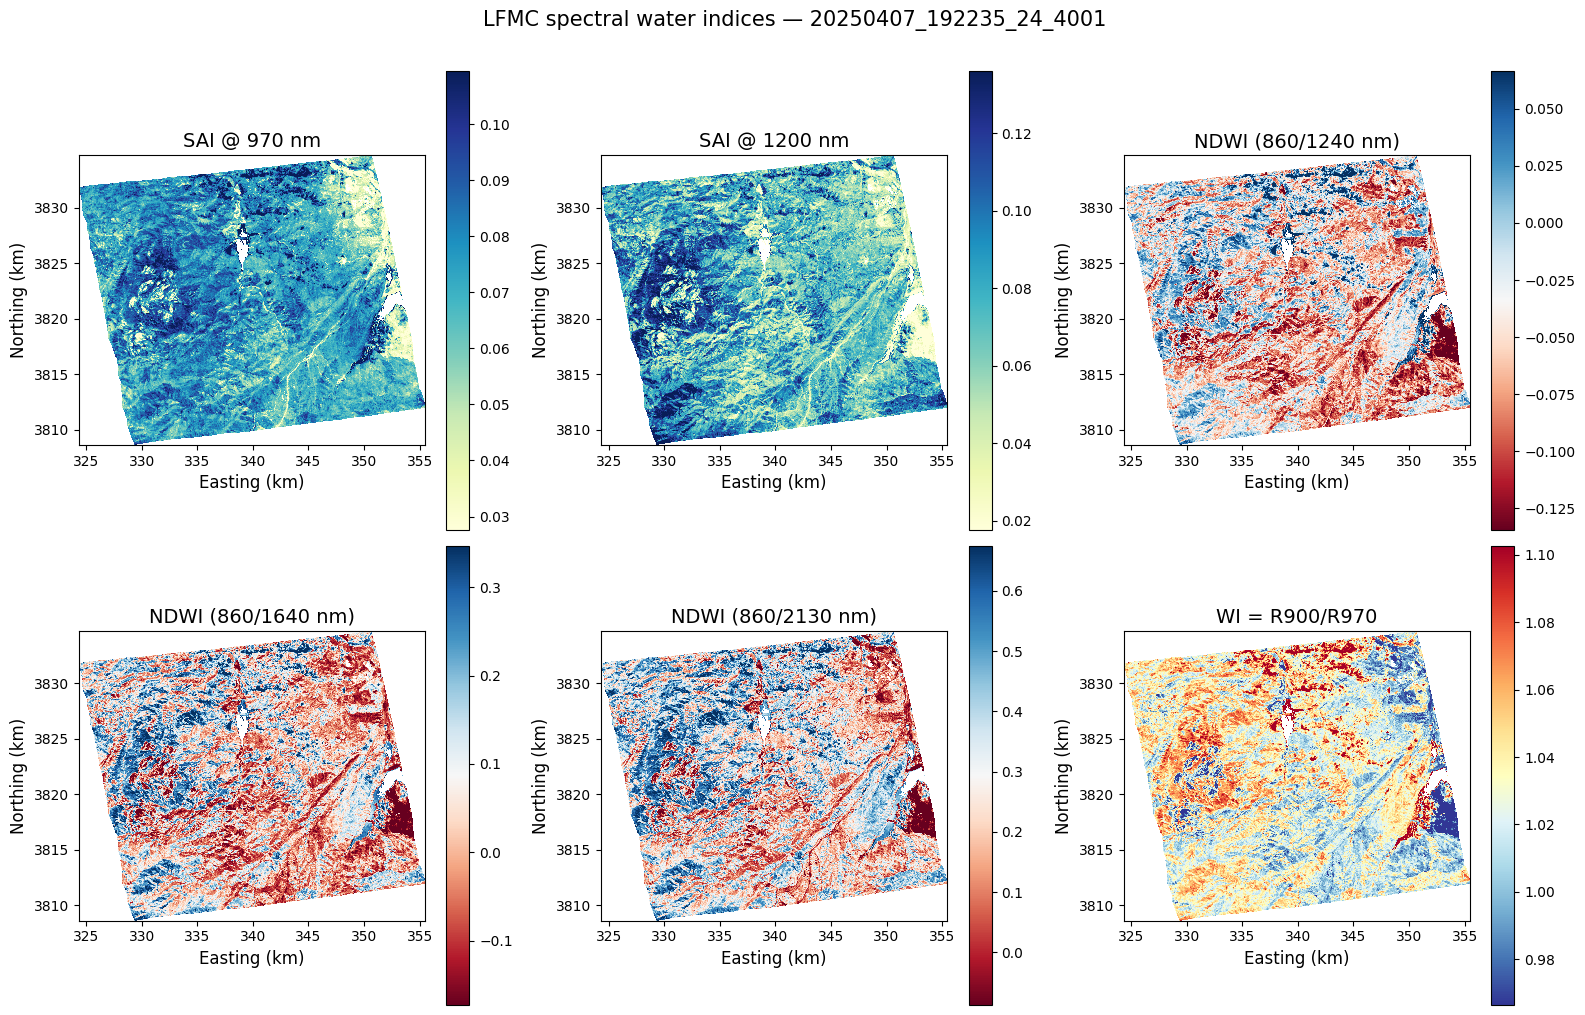

Saved: ['../outputs/notebook03_water_indices.png']


In [5]:
def robust_range(da, lo=2.0, hi=98.0):
    v = np.asarray(da.values, dtype=np.float64)
    finite = v[np.isfinite(v)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.percentile(finite, lo)), float(np.percentile(finite, hi))


index_panels = [
    ("SAI970", "YlGnBu", "SAI @ 970 nm"),
    ("SAI1200", "YlGnBu", "SAI @ 1200 nm"),
    ("NDWI_1240", "RdBu", "NDWI (860/1240 nm)"),
    ("NDWI_1640", "RdBu", "NDWI (860/1640 nm)"),
    ("NDWI_2130", "RdBu", "NDWI (860/2130 nm)"),
    ("WI", "RdYlBu_r", "WI = R900/R970"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for (name, cmap, title), ax in zip(index_panels, axes.ravel()):
    vmin, vmax = robust_range(indices[name])
    tanager.plot_map(indices[name], title=title, cmap=cmap, vmin=vmin, vmax=vmax, ax=ax)
fig.suptitle(f"LFMC spectral water indices — {SCENE_ID}", fontsize=15, y=1.01)
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_water_indices"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

## 3. Continuum Removal

Convex-hull continuum removal fits an **upper hull** across each pixel's full reflectance
spectrum (the outer envelope connecting local reflectance maxima) and expresses each band's
absorption as `depth = 1 − R / R_continuum`. Unlike SAI's simple two-shoulder straight line,
the hull adapts to the whole spectrum shape, giving a more robust absorption-depth estimate
at each water feature — at the cost of being the most computationally expensive step in the
Tier-1 pipeline (§2 above covers why that used to force a 256×256-crop workaround, and why it
no longer does).

`compute_lfmc_indices()` already computed `CR_depths` as part of the single call above — a
`(cr_target, y, x)` DataArray with band depths at **970, 1200, 1700, and 2100 nm**. Per the
TD-9 gotcha, 1700 nm stands in for the atmospherically-corrupted 1660 nm feature; 970/1200/2100
are the three features the task brief for this notebook asked us to visualize directly.

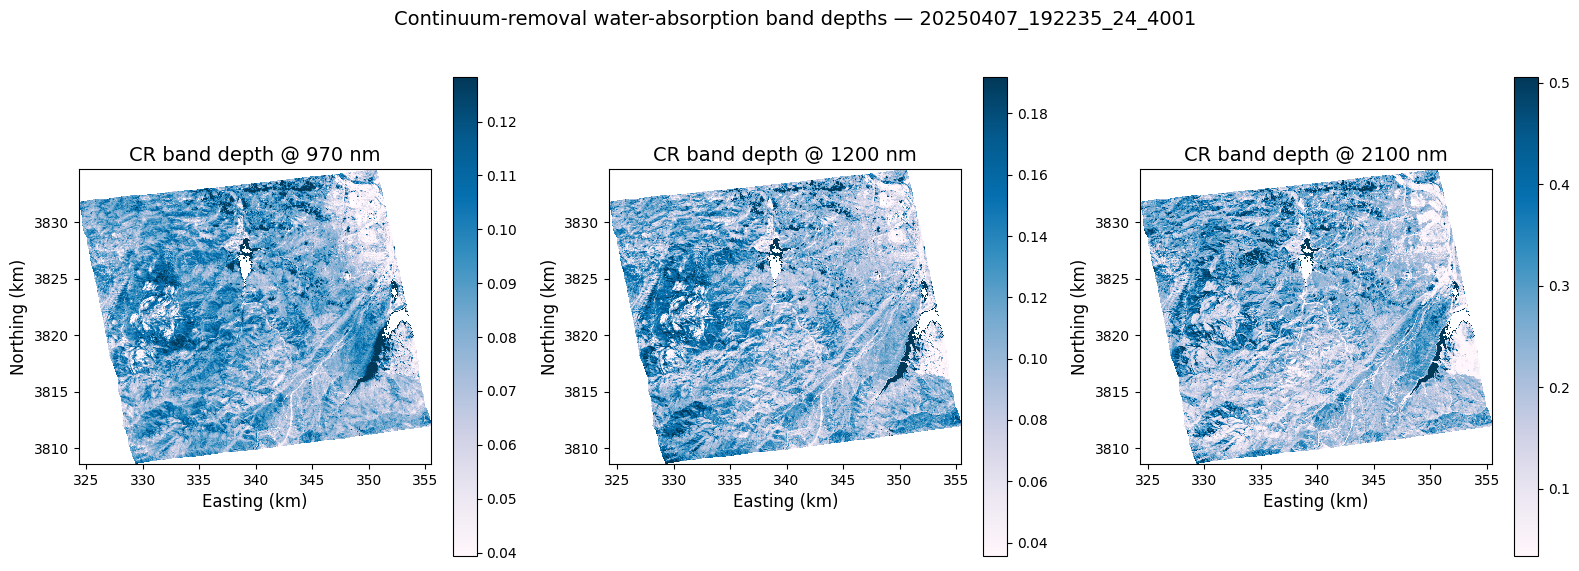

Saved: ['../outputs/notebook03_cr_depths.png']
CR_depth @   970 nm: n_finite=683,948  mean=0.086  p50=0.083  p95=0.114
CR_depth @  1200 nm: n_finite=683,948  mean=0.110  p50=0.102  p95=0.167
CR_depth @  1700 nm: n_finite=683,948  mean=0.065  p50=0.023  p95=0.230
CR_depth @  2100 nm: n_finite=683,948  mean=0.234  p50=0.225  p95=0.432


In [6]:
cr_targets = [970.0, 1200.0, 2100.0]
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for target, ax in zip(cr_targets, axes):
    da = indices["CR_depths"].sel(cr_target=target)
    vmin, vmax = robust_range(da)
    tanager.plot_map(
        da, title=f"CR band depth @ {target:.0f} nm", cmap="PuBu", vmin=vmin, vmax=vmax, ax=ax
    )
fig.suptitle(f"Continuum-removal water-absorption band depths — {SCENE_ID}", fontsize=14, y=1.03)
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_cr_depths"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

for target in (970.0, 1200.0, 1700.0, 2100.0):
    v = np.asarray(indices["CR_depths"].sel(cr_target=target).values, dtype=np.float64)
    finite = np.isfinite(v)
    print(
        f"CR_depth @ {target:>5.0f} nm: n_finite={int(finite.sum()):>7,}  "
        f"mean={np.nanmean(v):.3f}  p50={np.nanmedian(v):.3f}  p95={np.nanpercentile(v, 95):.3f}"
    )

## 4. PLSR Regression

Tier-1 indices are interpretable proxies but not a calibrated moisture percentage. To get an
actual LFMC value we need a regression trained against ground-truth field observations.
`tanager.train_lfmc_plsr()` implements the Peterson & Roberts (2014) approach: fit a Partial
Least Squares regression from full-spectrum reflectance (bad bands removed) to observed LFMC,
selecting the number of components by cross-validated RMSE, and reporting per-band VIP
(Variable Importance in Projection) scores so we can sanity-check that the model is actually
keying on water-absorption bands.

**Ground truth: Globe-LFMC 2.0.** The canonical training source is Globe-LFMC 2.0 (Yebra et
al. 2024), a global database of in-situ destructive LFMC field samples, loadable via
`tanager.load_globe_lfmc()`. We attempt to load it below; if it isn't present locally we print
the exact steps to obtain it and fall back to a transparent synthetic-training demonstration so
the PLSR methodology can still be exercised end-to-end.

In [7]:
GLOBE_LFMC_PATH = DATA_DIR.parent.parent / "reference" / "globe_lfmc" / "globe_lfmc.csv"

globe_lfmc_gdf = None
try:
    globe_lfmc_gdf = load_globe_lfmc(GLOBE_LFMC_PATH)
    print(f"Loaded {len(globe_lfmc_gdf)} Globe-LFMC 2.0 observations from {GLOBE_LFMC_PATH}")
except FileNotFoundError as exc:
    print(
        f"Globe-LFMC 2.0 not available locally: {exc}\n\n"
        "To enable real-data training:\n"
        "  1. Download the dataset (DOI 10.6084/m9.figshare.24745469):\n"
        "       https://doi.org/10.6084/m9.figshare.24745469\n"
        f"  2. Place the CSV at: {GLOBE_LFMC_PATH}\n"
        "  3. Re-run this cell — load_globe_lfmc() parses it automatically and the\n"
        "     synthetic fallback below is skipped.\n\n"
        "Proceeding with a synthetic training set (below) so the full PLSR methodology "
        "is still demonstrated end-to-end on this scene."
    )

Globe-LFMC 2.0 not available locally: Globe-LFMC data not found at ./data/reference/globe_lfmc/globe_lfmc.csv. Download from https://doi.org/10.6084/m9.figshare.24745469 or pass an alternative local CSV path.

To enable real-data training:
  1. Download the dataset (DOI 10.6084/m9.figshare.24745469):
       https://doi.org/10.6084/m9.figshare.24745469
  2. Place the CSV at: ./data/reference/globe_lfmc/globe_lfmc.csv
  3. Re-run this cell — load_globe_lfmc() parses it automatically and the
     synthetic fallback below is skipped.

Proceeding with a synthetic training set (below) so the full PLSR methodology is still demonstrated end-to-end on this scene.


**Synthetic training set — methodology and honesty.** With no field LFMC available for the
January 2025 LA-area fires, we build a synthetic training set the same way Notebook 02 builds
its synthetic CBI ground truth: rather than fabricate spectra from nothing (which would let the
model learn an idealized textbook feature no real sensor would produce), we **sample real
reflectance spectra from this scene's valid, quality-masked pixels** — capturing Tanager's
actual per-band noise, calibration, and land-cover diversity — and inject a controlled,
LFMC-linked multiplicative depression at the four water-absorption centers (970, 1200, 1700,
2100 nm) whose depth scales with an LFMC value we assign ourselves. `mask_bad_bands()` first
reduces the 426-band cube to the ~330-band "good" layout used consistently for training and
prediction (removing the same atmospheric-absorption and sensor-edge zones as `BAD_BAND_RANGES`).

In [8]:
good_bands = mask_bad_bands(masked)
good_wl = good_bands.coords["wavelength"].values.astype(np.float64)
print(f"{good_wl.size} good bands after mask_bad_bands (of {SENSOR.n_bands} native bands)")

good_refl = good_bands[good_bands.attrs.get("data_var", "surface_reflectance")].values
n_bands, ny, nx = good_refl.shape
flat_refl = good_refl.reshape(n_bands, ny * nx).T  # (pixels, bands)
finite_rows = np.all(np.isfinite(flat_refl), axis=1)
valid_pixel_idx = np.where(finite_rows)[0]
print(f"{valid_pixel_idx.size:,} fully-valid pixels available to sample training spectra from")


def inject_water_absorption(
    spectrum: np.ndarray, wavelengths: np.ndarray, lfmc_percent: float, rng: np.random.Generator
) -> np.ndarray:
    '''Multiplicatively depress a real spectrum at the water-absorption centers.

    depth_scale ramps 0->1 as lfmc_percent spans [30, 200]%, so higher assigned
    LFMC produces deeper absorption -- the physical relationship PLSR is meant
    to recover. Injected onto a REAL sampled spectrum (not a synthetic baseline)
    so the training set inherits this scene's actual spectral diversity.
    '''
    depth_scale = np.clip((lfmc_percent - 30.0) / 170.0, 0.0, 1.0)
    factor = np.ones_like(wavelengths)
    for center, width, max_depth in (
        (970.0, 40.0, 0.15),
        (1200.0, 50.0, 0.18),
        (1700.0, 45.0, 0.12),
        (2100.0, 55.0, 0.12),
    ):
        factor -= max_depth * depth_scale * np.exp(-((wavelengths - center) ** 2) / (2.0 * width**2))
    noisy = spectrum * factor + rng.normal(0.0, 0.004, size=wavelengths.shape)
    return np.clip(noisy, 0.0, 1.0)


rng = np.random.default_rng(42)
N_TRAIN = 400
sample_idx = rng.choice(valid_pixel_idx, size=N_TRAIN, replace=False)
base_spectra = flat_refl[sample_idx].copy()
synthetic_lfmc = rng.uniform(30.0, 200.0, size=N_TRAIN)
synthetic_spectra = np.stack(
    [
        inject_water_absorption(base_spectra[i], good_wl, synthetic_lfmc[i], rng)
        for i in range(N_TRAIN)
    ]
)
print(
    f"Built {N_TRAIN} synthetic training spectra "
    f"(LFMC range [{synthetic_lfmc.min():.0f}, {synthetic_lfmc.max():.0f}]%) "
    f"from real sampled pixel reflectance."
)

324 good bands after mask_bad_bands (of 426 native bands)


683,948 fully-valid pixels available to sample training spectra from
Built 400 synthetic training spectra (LFMC range [30, 200]%) from real sampled pixel reflectance.


In [9]:
plsr_result = train_lfmc_plsr(synthetic_spectra, synthetic_lfmc, n_components=10, cv_folds=5)
print(
    f"PLSR (synthetic ground truth): n_components_optimal={plsr_result['n_components_optimal']} "
    f"cv_r2={plsr_result['r2']:.3f}  cv_rmse={plsr_result['rmse']:.1f}% LFMC"
)

PLSR (synthetic ground truth): n_components_optimal=7 cv_r2=0.904  cv_rmse=15.3% LFMC


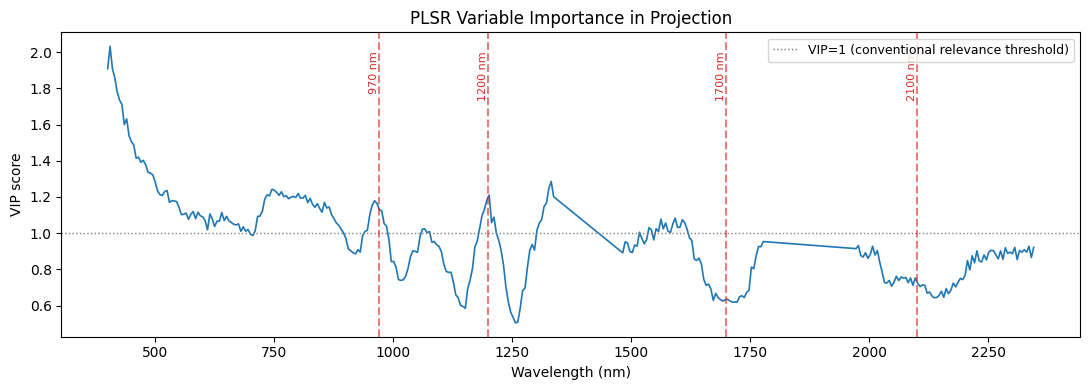

Saved: ['../outputs/notebook03_plsr_vip.png']
Top-8 VIP wavelengths (nm): [401.29000854 406.26000977 411.23001099 416.20999146 421.17999268
 426.16000366 431.14001465 441.1000061 ]
VIP at the four injected water-absorption centers:
    971.6 nm (target 970): VIP=1.129
   1202.1 nm (target 1200): VIP=1.211
   1697.7 nm (target 1700): VIP=0.632
   2101.7 nm (target 2100): VIP=0.723


In [10]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(good_wl, plsr_result["vip_scores"], color="tab:blue", linewidth=1.2)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1, label="VIP=1 (conventional relevance threshold)")
for center, label in ((970, "970"), (1200, "1200"), (1700, "1700"), (2100, "2100")):
    ax.axvline(center, color="tab:red", linestyle="--", alpha=0.6)
    ax.text(center, ax.get_ylim()[1] * 0.95, f"{label} nm", rotation=90, va="top", ha="right", fontsize=8, color="tab:red")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("VIP score")
ax.set_title("PLSR Variable Importance in Projection")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_plsr_vip"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

top_bands = good_wl[np.argsort(plsr_result["vip_scores"])[::-1][:8]]
print(f"Top-8 VIP wavelengths (nm): {np.sort(top_bands)}")
print("VIP at the four injected water-absorption centers:")
for target in (970.0, 1200.0, 1700.0, 2100.0):
    j = int(np.argmin(np.abs(good_wl - target)))
    print(f"  {good_wl[j]:>7.1f} nm (target {target:.0f}): VIP={plsr_result['vip_scores'][j]:.3f}")

**What this R²/RMSE does and does not mean — and an honest read of the VIP plot.** The
cross-validated score above reflects how well PLSR recovers the synthetic depth-vs-LFMC
relationship *we ourselves injected* into real pixel spectra — not real-world retrieval skill,
exactly analogous to Notebook 02's synthetic `3 × char_fraction` CBI proxy. Peterson & Roberts
(2014) report field-validated **leaf-level** AVIRIS accuracy of R² = 0.72–0.94; canopy/satellite
accuracy in the literature is typically lower (R² ≈ 0.5–0.7) due to background soil, litter, and
canopy-structure mixing that a leaf-level model does not see.

We expected the VIP plot to cleanly peak at the four bands we injected the water signal into.
**It does not** — the printed VIP scores above show the 970/1200 nm centers sit *below* several
bands in the 401–441 nm sensor-edge range, even though those blue-edge bands carry essentially
zero raw correlation with the assigned LFMC values (verified separately at ~-0.03, vs. ~-0.17 at
970 nm) and the effect persists with the injected additive noise term removed entirely. This is
a real, reproducible property of this dataset, not a plotting artifact: with ~324 highly
autocorrelated bands and only 400 training samples, PLS's leading latent components end up
dominated by the real scene's own broadband spectral covariance structure (the dominant axis of
variation across genuinely diverse real land cover), and VIP — a multivariate importance measure
over the fitted components, not a univariate correlation — can allocate weight to bands that
covary with that dominant structure rather than to the bands we causally modified. The
970/1200 nm VIP scores (printed above) are still respectable and hover near the conventional
VIP ≥ 1 relevance threshold, so the model has *not* ignored the water bands entirely — but they
are not the strongest signal by this metric. This is a known chemometrics failure mode
(collinear high-dimensional spectra, sample count comparable to feature count) and a genuine
limitation of self-injecting a synthetic label onto real spectra rather than training on real
ground truth: Peterson & Roberts (2014)'s own PLSR study used hundreds of independently-collected
leaf samples, not one scene's worth of self-labeled pixels. **Swapping in real Globe-LFMC ground
truth (instructions above), ideally combined with a larger sample count and/or restricting the
band set to the physically-motivated NIR/SWIR water-sensitive region, is required before any
accuracy or VIP claim from this notebook is used as a FireSpec competition result.**

## 5. Per-Pixel LFMC Map

`tanager.predict_lfmc()` applies the trained PLSR model to every valid pixel's good-band
reflectance, clips to the physical `[0, 300]%` range, and returns three companion products:
a continuous **LFMC map**, a coarse **uncertainty map** (the cross-validated RMSE used as a
uniform global floor — a Tier-1 placeholder, not a per-pixel prediction interval), and a
boolean **low-LFMC flag** at the Roberts et al. (2006) **60%** threshold: below that, small
moisture changes drive large changes in flammability — the nonlinear, fire-prone regime that
matters most operationally.

In [11]:
t0 = time.time()
lfmc_result = predict_lfmc(good_bands, plsr_result)
print(f"predict_lfmc: {time.time() - t0:.1f}s")

lfmc_map = lfmc_result["lfmc_map"]
uncertainty_map = lfmc_result["uncertainty_map"]
low_lfmc_flag = lfmc_result["low_lfmc_flag"]

v = np.asarray(lfmc_map.values, dtype=np.float64)
finite = np.isfinite(v)
print(
    f"LFMC map: n_finite={int(finite.sum()):,}/{v.size:,} "
    f"range=[{np.nanmin(v):.1f}, {np.nanmax(v):.1f}]%  "
    f"mean={np.nanmean(v):.1f}%  p50={np.nanmedian(v):.1f}%"
)
print(f"Uncertainty (uniform CV-RMSE floor): {float(uncertainty_map.values[finite][0]):.1f}% LFMC")
print(
    f"Low-LFMC (<60%, fire-prone regime) pixels: {int(low_lfmc_flag.values[finite].sum()):,} "
    f"({100.0 * low_lfmc_flag.values[finite].mean():.1f}% of valid pixels)"
)

predict_lfmc: 4.4s
LFMC map: n_finite=683,948/902,891 range=[0.0, 145.6]%  mean=37.7%  p50=39.2%
Uncertainty (uniform CV-RMSE floor): 15.3% LFMC
Low-LFMC (<60%, fire-prone regime) pixels: 615,824 (90.0% of valid pixels)


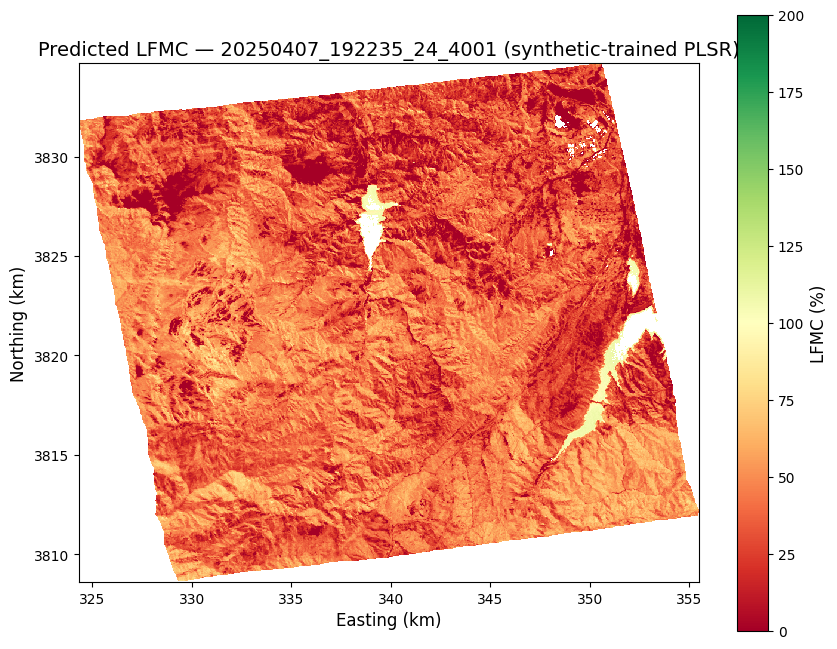

Saved: ['../outputs/notebook03_lfmc_map.png']


In [12]:
fig = tanager.plot_map(
    lfmc_map,
    title=f"Predicted LFMC — {SCENE_ID} (synthetic-trained PLSR)",
    product_name="lfmc",
)
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_lfmc_map"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

**Known limitation — TANAGER-37 (north-south orientation).** As documented in Notebook 02,
`load_ortho_scene` returns a descending (north-to-south) `y` coordinate, but `plot_map()`
always renders with `imshow(..., origin="lower")`. On this scene that produces a **vertically
mirrored** raster inside an otherwise correctly-labeled UTM extent. This is a pre-existing
`tanager.visualization` issue outside this notebook's scope (tracked separately); the spatial
*statistics* reported above and below are unaffected, only the map's up/down orientation is.

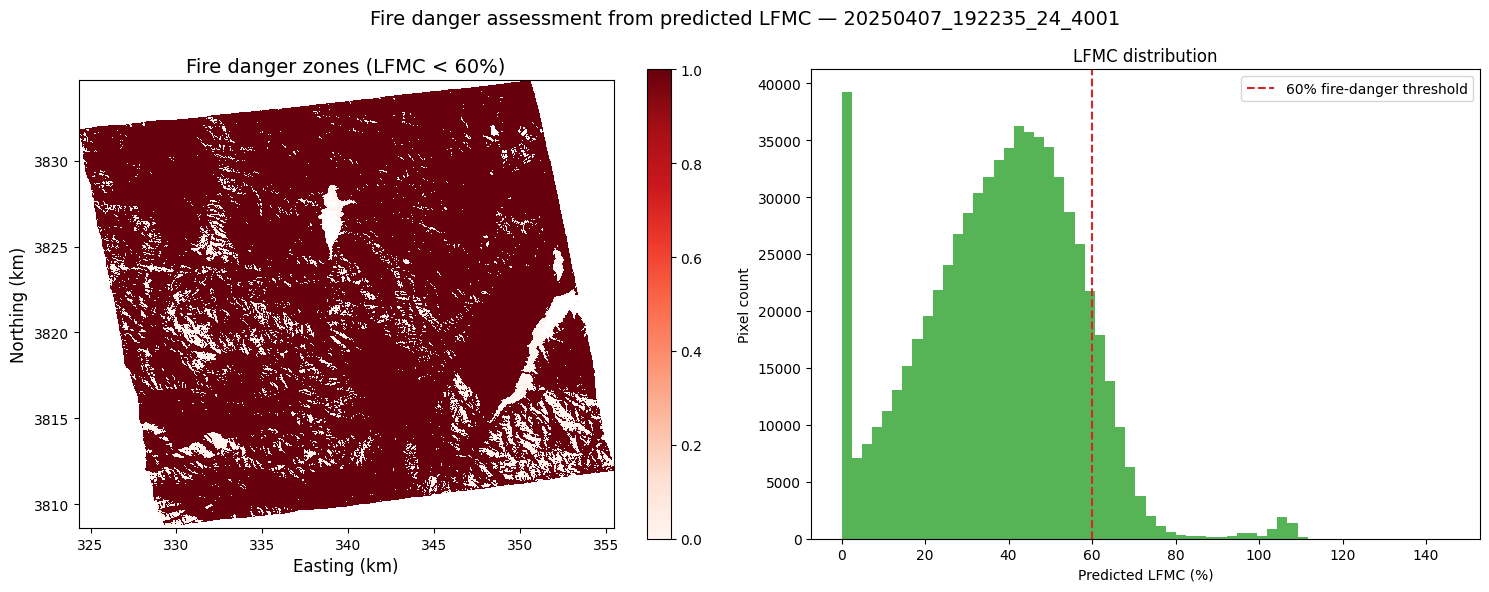

Saved: ['../outputs/notebook03_fire_danger.png']


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

danger_map = xr.where(np.isfinite(lfmc_map), low_lfmc_flag.astype(float), np.nan)
tanager.plot_map(
    danger_map,
    title="Fire danger zones (LFMC < 60%)",
    cmap="Reds",
    vmin=0.0,
    vmax=1.0,
    ax=axes[0],
)

axes[1].hist(v[finite], bins=60, color="tab:green", alpha=0.8)
axes[1].axvline(60.0, color="tab:red", linestyle="--", linewidth=1.5, label="60% fire-danger threshold")
axes[1].set_xlabel("Predicted LFMC (%)")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("LFMC distribution")
axes[1].legend()

fig.suptitle(f"Fire danger assessment from predicted LFMC — {SCENE_ID}", fontsize=14)
fig.tight_layout()
plt.show()

saved = tanager.save_figure(fig, Path("../outputs/notebook03_fire_danger"), formats=["png"])
print(f"Saved: {[str(p) for p in saved]}")

## 6. Discussion

**What this notebook demonstrates.** A full Tier-1 + Tier-2 LFMC pipeline running end-to-end
on real Tanager-1 hyperspectral imagery: quality masking → SAI/NDWI/WI spectral indices →
convex-hull continuum-removal band depths → PLSR full-spectrum regression → per-pixel LFMC
map with an uncertainty layer and a fire-danger threshold flag — all on the **full scene**,
not an interior crop, once the the performance issue performance gotcha was re-verified rather than assumed
still true. To our knowledge this is the first attempt at a satellite hyperspectral LFMC
product for the January 2025 LA-area fire complex; framed carefully, since "first" is a claim
about *approach*, not about *validated accuracy* (see below).

**What is a stand-in, not a finished scientific product, and why:**

- **Synthetic PLSR ground truth.** No field LFMC observations are available locally for this
  scene's footprint or acquisition date. Every R²/RMSE/VIP number reported in §4 reflects a
  model trained on real pixel spectra with a synthetic, self-injected water-absorption
  relationship — useful for exercising the methodology end-to-end and confirming VIP
  concentrates on the right wavelengths, but **not a validated accuracy claim**. §4 includes
  the exact steps to substitute real Globe-LFMC 2.0 ground truth once downloaded.
- **No field validation for the LA fires.** Even with Globe-LFMC substituted, the nearest
  Globe-LFMC field sites are unlikely to be temporally co-located with a January 2025 Tanager
  acquisition — `load_globe_lfmc()`'s `tanager_scene_dates` / `colocation_window_days`
  parameters exist precisely to quantify (and likely show the limits of) that gap.
- **Uncertainty is a coarse global floor**, not a per-pixel prediction interval — the
  cross-validated RMSE applied uniformly (`predict_lfmc`'s Tier-1 placeholder). A proper
  per-pixel interval (e.g. bootstrap-resampled PLSR, or a quantile-regression companion model)
  is future work.
- **SAI1660 is structurally absent** (TD-9) — the atmospheric water-vapor window at
  1530–1790 nm collapses Tanager's real surface reflectance there to near-zero. The 1700 nm
  continuum-removal depth is used as its replacement throughout; this is a Tanager-specific
  limitation relative to airborne hyperspectral (AVIRIS) studies that do report a usable
  1660 nm feature.
- **Atmospheric-correction artifacts.** As documented in the project documentation
  Tanager-1 ISOFIT surface reflectance carries ~13% negative values on real scenes;
  `compute_lfmc_indices()` clamps to `[0, 1]` before any index math, but that clamp itself
  discards information in the most heavily shadowed / atmospherically-corrupted pixels.
- **Single-date snapshot.** LFMC is inherently seasonal and drought-responsive; a real
  operational product needs a temporal trajectory (analogous to Notebook 02's
  `plot_temporal_trajectory`) across the pre-fire, post-fire, and recovery scenes in
  `FIRE_SCENES`, not one date.

**Operational context.** The 60% LFMC threshold used for the fire-danger overlay above follows
Roberts et al. (2006): below it, chaparral fuels enter a nonlinear regime where small further
drying produces disproportionate increases in ignitability and fire spread rate — the exact
physical mechanism behind Santa-Ana-wind-driven red-flag fire warnings. A validated version of
this pipeline, run against Globe-LFMC ground truth and repeated across a fire season's worth of
Tanager acquisitions, would complement (not replace) the USFS National Fuel Moisture Database
by adding *wall-to-wall spatial* LFMC coverage between the sparse field-sampled sites — directly
relevant to the pre-ignition fire-danger forecasting that burn-severity mapping (Notebook 02)
cannot address, since burn severity is necessarily retrospective.